In [ ]:
def drop_trials(epochs, chs=[0], do_peak=0, do_mean=0, do_slope=0, T1=0, T2=0, iter_inf=False):
    # Create a copy of epochs
    
    from scipy.stats import iqr
    from scipy.stats import median_abs_deviation as mad

    new_epochs = epochs.copy()
    # Create a list to keep track of trial status (1 for good trials, 0 for rejected trials)
    list_trials = np.ones(len(new_epochs))

    for j in chs:
        # Initialize variables for peak rejection
        peak_rejection = 0
        mean_rejection = 0
        slope_rejection = 0
        ite_peak = 0
        ite_mean = 0
        ite_slope = 0
        stop_peak = 0
        stop_mean = 0
        stop_slope = 0
        ite_loop = 0

        # Main loop for outlier detection and rejection
        while ite_mean > -1:
            ite_loop += 1

            if do_peak == 1:
                if ite_peak == 0:
                    # Calculate time indices based on T1 and T2 values
                    time1 = np.where(new_epochs.times < T1)[0][-1]
                    time2 = np.where(new_epochs.times < T2)[0][-1]

                    # Calculate peak-to-peak values for each trial and channel
                    peak_to_peak = np.array([max(new_epochs._data[i][j][time1:time2]) - min(new_epochs._data[i][j][time1:time2]) for i in range(len(new_epochs._data))], dtype=np.dtype(float))

                idx = []
                for i in range(len(new_epochs._data)):
                    value_prtp = peak_to_peak[i]

                    # Check if the value exceeds the upper threshold for peak rejection
                    
                    Q1, Q3 = np.nanquantile(peak_to_peak,[.25,.75])
                    outlier_up_peak = Q3 + (2 * iqr(peak_to_peak, nan_policy='omit'))
                    if value_prtp  > outlier_up_peak : #append good trials to keep them 
                        idx.append(i)

                if len(idx) == 0:
                    # No more outliers found, stop peak outlier detection
                    stop_peak = 1
                else:
                    ite_peak += 1
                    peak_to_peak[idx] = None
                    list_trials[idx] = 0
                    peak_rejection += len(idx)

            if do_slope == 1:
                if ite_slope == 0:
                    # Calculate time indices based on T1 and T2 values
                    time1 = np.where(new_epochs.times < T1)[0][-1]
                    time2 = np.where(new_epochs.times < T2)[0][-1]

                    x = new_epochs.times[time1:time2]
                    # Calculate slopes for each trial and channel
                    slopes_trials = np.array([np.polyfit(x, new_epochs._data[i, j, time1:time2], 1)[0] for i in range(len(new_epochs._data))], dtype=np.dtype(float))

                idx = []
                for i in range(len(new_epochs._data)):
                    value_prtp = slopes_trials[i]

                    # Check if the value exceeds the upper and lower thresholds for slope rejection
                    
                    Q1, Q3 = np.nanquantile(slopes_trials,[.25,.75])
                    outlier_up_mean = Q1 +(2 * iqr(slopes_trials, nan_policy='omit'))
                    outlier_down_mean = Q3 - (2 * iqr(slopes_trials, nan_policy='omit'))
                    if value_prtp > outlier_up_mean :
                        idx.append(i)
                    elif value_prtp < outlier_down_mean :
                        idx.append(i)

                if len(idx) == 0:
                    # No more outliers found, stop slope outlier detection
                    stop_slope = 1
                else:
                    ite_slope += 1
                    slopes_trials[idx] = None
                    list_trials[idx] = 0
                    slope_rejection += len(idx)

            if do_mean == 1:
                if ite_mean == 0:
                    # Calculate time indices based on T1 and T2 values
                    time1 = np.where(new_epochs.times < T1)[0][-1]
                    time2 = np.where(new_epochs.times < T2)[0][-1]
                    # Calculate mean values for each trial and channel
                    mean_trials = np.array([np.mean(new_epochs._data[i][j][time1:time2]) for i in range(len(new_epochs._data))], dtype=np.dtype(float))

                idx = []
                for i in range(len(new_epochs._data)):
                    value_prtp = mean_trials[i]

                    # Check if the value exceeds the upper and lower thresholds for mean rejection
                    Q1, Q3 = np.nanquantile(mean_trials,[.25,.75])
                    outlier_up_mean = Q3 + (2 * iqr(mean_trials, nan_policy='omit'))
                    outlier_down_mean = Q1 - (2 * iqr(mean_trials, nan_policy='omit'))
                    if value_prtp > outlier_up_mean:
                        idx.append(i)
                    elif value_prtp < outlier_down_mean:
                        idx.append(i)

                if len(idx) == 0:
                    # No more outliers found, stop mean outlier detection
                    stop_mean = 1
                else:
                    ite_mean += 1
                    mean_trials[idx] = None
                    list_trials[idx] = 0
                    mean_rejection += len(idx)

            # Check if any outlier detection is disabled
            if do_peak == 0 | iter_inf == False :
                stop_peak = 1
            if do_mean == 0 | iter_inf == False:
                stop_mean = 1
            if do_slope == 0 | iter_inf == False:
                stop_slope = 1

            # Check if all outlier detection has stopped
            if stop_mean == 1 and stop_peak == 1 and stop_slope == 1:
                # No more outlier detection, stop the loop
                break

    # Drop the trials marked for removal and return the modified epochs object
    new_epochs.drop(np.where(list_trials == 0)[0])
    return new_epochs, peak_rejection, mean_rejection, slope_rejection, list_trials, ite_loop


In [1]:
# Import the required libraries
import os, mne, csv
import numpy as np
import pandas as pd 
from mne.channels import make_standard_montage
from glob import glob
from scipy import stats
from scipy.stats import iqr, median_abs_deviation as mad
from mne.time_frequency import tfr_morlet
import matplotlib.pyplot as plt
#set directory pathway
os.chdir('C:/Users/mfbpe/Desktop/DATA/2023_Eva_Freedom/derivatives')


data_files = glob('*_raw.fif')


In [ ]:
raw = mne.io.read_raw_fif(data_files[0], preload=True)

raw.set_eeg_reference()
event_dict = { 'action/free':17,'action/recommended':18,'action/semi-instructed':19,'action/instructed':20, 'vizualisation/free':1,'vizualisation/recommended':2,'vizualisation/semi-instructed':3,'vizualisation/instructed':4}

events,event_dict = mne.events_from_annotations(raw, event_dict)
event_dict_action = { 'action/free':17,'action/recommended':18,'action/semi-instructed':19,'action/instructed':20} 
event_dict_visualization = {'vizualisation/free':1,'vizualisation/recommended':2,'vizualisation/semi-instructed':3,'vizualisation/instructed':4} 

Opening raw data file sub-17_constraint_raw.fif...
    Range : 0 ... 1677385 =      0.000 ...  3276.143 secs
Ready.
Reading 0 ... 1677385  =      0.000 ...  3276.143 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('action/free'), np.str_('action/instructed'), np.str_('action/recommended'), np.str_('action/semi-instructed'), np.str_('vizualisation/free'), np.str_('vizualisation/instructed'), np.str_('vizualisation/recommended'), np.str_('vizualisation/semi-instructed')]


In [14]:

epochs = mne.Epochs(raw, events, baseline=None, event_id=event_dict_action
                    , tmin=-3, tmax=2,
                    preload=True, detrend=None, event_repeated='drop', on_missing='ignore')

# Apply baseline correction to the epochs data
epochs.apply_baseline((-2, -1.8))

Not setting metadata
276 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 276 events and 2561 original time points ...


0 bad epochs dropped
Applying baseline correction (mode: mean)


<Epochs | 276 events (all good), -3 – 2 s (baseline -2 – -1.8 s), ~350.6 MiB, data loaded,
 'action/free': 69
 'action/recommended': 69
 'action/semi-instructed': 69
 'action/instructed': 69>

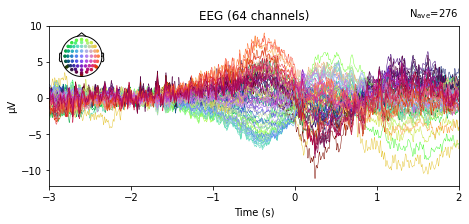

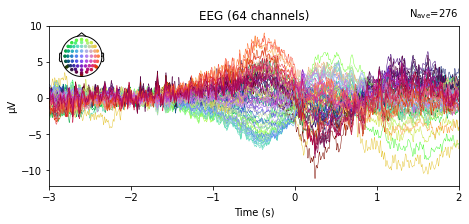

In [15]:
epochs.average().plot()

In [6]:
avg_RP = np.mean(epochs.average()._data[:,epochs.time_as_index(-1)[0]:epochs.time_as_index(0)[0]])

In [7]:
list_peak = np.mean(epochs.average()._data[:,epochs.time_as_index(-1)[0]:epochs.time_as_index(0)[0]],1)


In [8]:
chs_RP = np.array(epochs.ch_names)[np.where(avg_RP > list_peak)[0]]
chs_RP

array(['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'FC5', 'FC3', 'FC1', 'C1',
       'C3', 'CP3', 'CP1', 'P1', 'P3', 'CPz', 'Fpz', 'Fp2', 'AF4', 'AFz',
       'Fz', 'F2', 'F4', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'CP4', 'CP2'],
      dtype='<U6')

combining channels using "mean"


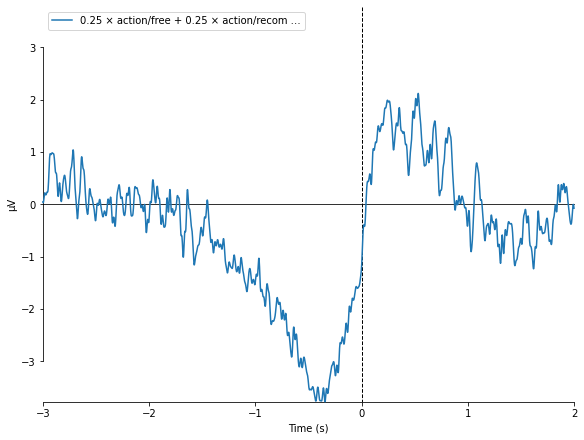

[<Figure size 576x432 with 1 Axes>]

In [16]:
mne.viz.plot_compare_evokeds(epochs.average().pick(chs_RP), combine = "mean")

In [17]:
epochs_viz = mne.Epochs(raw, events, baseline=None, event_id=event_dict_visualization, tmin=-2, tmax=0, picks="eeg",
                    preload=True, detrend=None, event_repeated='drop', on_missing='ignore').pick("eeg")
epochs_viz.apply_baseline((-1.2,0))

epochs_act = mne.Epochs(raw, events, baseline=None, event_id=event_dict_action, tmin=-2.4, tmax=-.4, picks= "eeg",
                    preload=True, detrend=None, event_repeated='drop', on_missing='ignore').pick("eeg")
epochs_act.shift_time(.4).apply_baseline((-1.2,0))

Not setting metadata


276 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 276 events and 1025 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Not setting metadata
276 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 276 events and 1025 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


<Epochs | 276 events (all good), -2 – -0 s (baseline -1.2 – 0 s), ~138.2 MiB, data loaded,
 'action/free': 69
 'action/recommended': 69
 'action/semi-instructed': 69
 'action/instructed': 69>

combining channels using "mean"


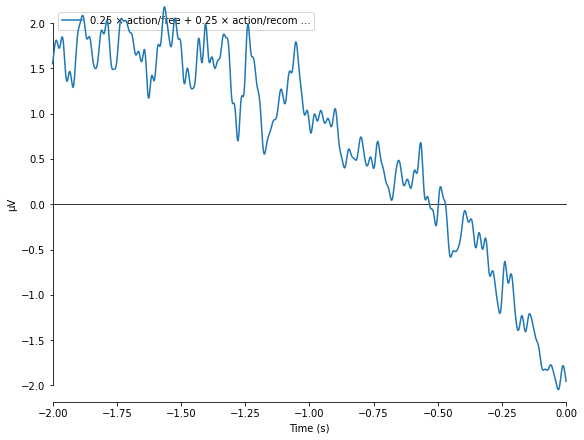

combining channels using "mean"


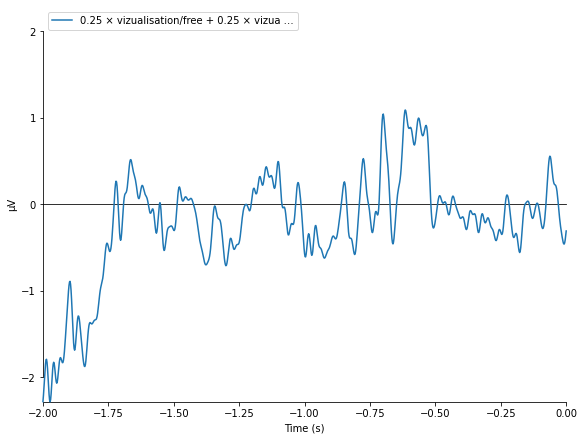

In [19]:
for i in [epochs_act, epochs_viz]:
    mne.viz.plot_compare_evokeds([i.copy().pick(chs_RP).average()], combine = "mean")

In [20]:
movement = np.array([np.mean(epochs_act._data[:,:,epochs_act.time_as_index(-1.2+i/10)[0]: epochs_act.time_as_index(-1.1+i/10)[0]], 2) for i in range(12)])
no_movement = np.array([np.mean(epochs_viz._data[:,:,epochs_viz.time_as_index(-1.2+i/10)[0]: epochs_viz.time_as_index(-1.1+i/10)[0]], 2) for i in range(12)])
no_movement = np.reshape(no_movement, [no_movement.shape[0], no_movement.shape[1]* no_movement.shape[2]])
movement = np.reshape(movement, [movement.shape[0], movement.shape[1]* movement.shape[2]])
no_movement.shape

(12, 17664)

In [21]:
movement = np.array([np.mean(epochs_act._data[:,:,epochs_act.time_as_index(-1.2)[0]: epochs_act.time_as_index(0)[0]], 2) ])
no_movement = np.array([np.mean(epochs_viz._data[:,:,epochs_viz.time_as_index(-1.2)[0]: epochs_viz.time_as_index(0)[0]], 2)])
no_movement = np.reshape(no_movement, [no_movement.shape[2], no_movement.shape[1]* no_movement.shape[0]])
movement = np.reshape(movement, [movement.shape[2], movement.shape[1]* movement.shape[0]])
movement.shape

(64, 276)

In [22]:
276*len(chs_RP)


8280

In [23]:
X = np.concatenate([np.transpose(movement, (1,0)),np.transpose(no_movement, (1,0))])
X.shape

(552, 64)

In [25]:
y = np.concatenate([np.ones(X.shape[0]//2),np.zeros(X.shape[0]//2)])
y.shape

(552,)

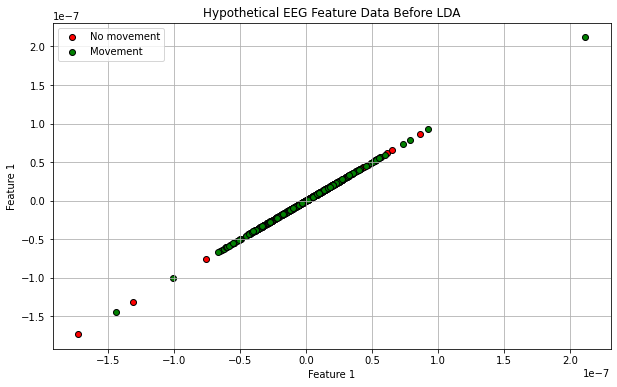

In [26]:

# Plotting the data before LDA
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 0], color='red', label='No movement', edgecolor='k')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 0], color='green', label='Movement', edgecolor='k')
plt.title("Hypothetical EEG Feature Data Before LDA")
plt.xlabel("Feature 1")
plt.ylabel("Feature 1")
plt.legend()
plt.grid(True)
plt.show()


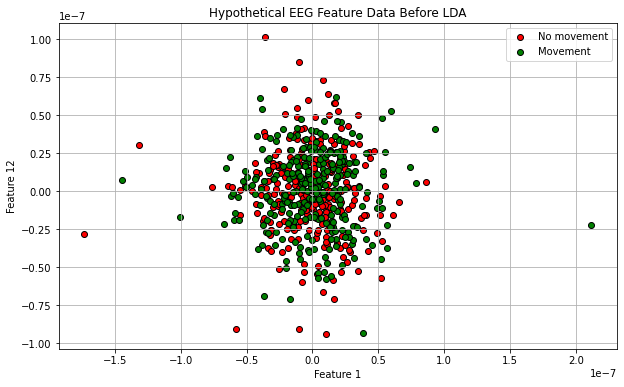

In [27]:

# Plotting the data before LDA
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 11], color='red', label='No movement', edgecolor='k')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 11], color='green', label='Movement', edgecolor='k')
plt.title("Hypothetical EEG Feature Data Before LDA")
plt.xlabel("Feature 1")
plt.ylabel("Feature 12")
plt.legend()
plt.grid(True)
plt.show()


Accuracy: 0.5797101449275363
Confusion Matrix:
[[155 121]
 [111 165]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.58      0.56      0.57       276
         1.0       0.58      0.60      0.59       276

    accuracy                           0.58       552
   macro avg       0.58      0.58      0.58       552
weighted avg       0.58      0.58      0.58       552



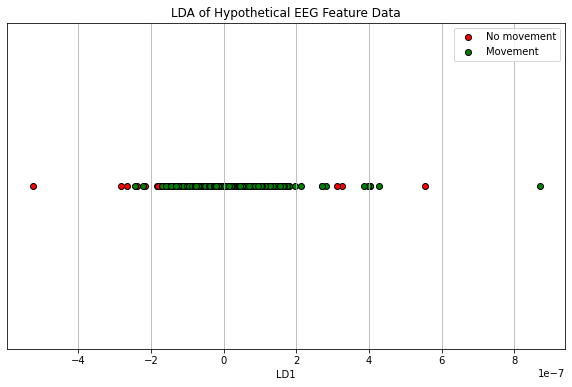

In [28]:

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,recall_score
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
import matplotlib.pyplot as plt
# Perform LDA and cross-validation
lda = LinearDiscriminantAnalysis(solver="eigen",n_components=1, shrinkage='auto')
lda.fit(X, y)

# Predictions
y_pred = lda.predict(X)

# Evaluate the model
accuracy = accuracy_score(y, y_pred)
conf_matrix = confusion_matrix(y, y_pred)
class_report = classification_report(y, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Plotting the results after LDA
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0], np.zeros(X[y == 0].shape), color='red', label='No movement', edgecolor='k')
plt.scatter(X[y == 1], np.zeros(X[y == 1].shape), color='green', label='Movement', edgecolor='k')
plt.title("LDA of Hypothetical EEG Feature Data")
plt.xlabel("LD1")
plt.yticks([])  # Hide y-axis
plt.legend()
plt.grid(True)
plt.show()

In [29]:
lda.coef_

array([[ 2016096.98972884,   -81586.4030306 ,  -363751.42225787,
          657479.3771879 , -2758391.80984637,   609971.21505926,
          868038.78273202, -1124253.75795302,    80029.6588159 ,
         -826549.67781971,  3770132.65612019,  -286384.57599967,
        -2030230.80315785,   -58969.58861684,   217329.79853112,
         -419874.21628878, -2018840.57882168,  -327846.94756829,
         1007596.38065969,  2090315.61368663,  -421332.87376269,
         -323891.70202602,  -925631.71262805, -1274936.35366971,
         2667950.06354566, -2891968.85542631,  1705481.660197  ,
         -771332.07195039,   359855.00832986,   656691.66552697,
        -1631084.31290641,  -487542.0432983 , -3608382.6965891 ,
         2959169.82838132, -1408437.04728278,   -67264.73512812,
          618669.39470443, -1447779.24696919,  -140970.11151954,
         3064118.40889625, -2731375.61443707,  3062111.72970128,
        -2100699.9853021 ,  1635778.9106782 ,  -879259.52948551,
          391935.02600049

# HERE WE TEST SVD SOLUTION 
<div class="alert alert-block alert-warning">
SEEMS SLIGHTLY BETTER 
</div>


In [37]:
epochs_viz = mne.Epochs(raw, events, baseline=None, event_id=event_dict_visualization, tmin=-2, tmax=0, picks=chs_RP,
                    preload=True, detrend=None, event_repeated='drop', on_missing='ignore').pick("eeg")
epochs_viz.apply_baseline((-1.2,0))

epochs_act = mne.Epochs(raw, events, baseline=None, event_id=event_dict_action, tmin=-2.4, tmax=-.4, picks=chs_RP,
                    preload=True, detrend=None, event_repeated='drop', on_missing='ignore').pick("eeg")
epochs_act.shift_time(.4).apply_baseline((-1.2,0))
eegdata_act = epochs_act._data
eegdata_viz = epochs_viz._data

Not setting metadata
276 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 276 events and 1025 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Not setting metadata
276 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 276 events and 1025 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [47]:

# Calculate ERP matrix
erp_matrix = np.mean(eegdata_act, axis=2)

u, s, v = np.linalg.svd(erp_matrix, full_matrices=0)
print(( np.square(s) / float(np.sum(np.square(s))) )[:5]*100)
component1_weights = v[0,:]
single_trial_erps_act = np.einsum('ijk,j->ik', eegdata_act, component1_weights)
single_trial_erps_viz = np.einsum('ijk,j->ik', eegdata_viz, component1_weights)


[27.48859695 19.12413847 10.81655223  8.18525512  5.81045721]


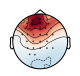

(<matplotlib.image.AxesImage at 0x20c9c075270>,
 <matplotlib.contour.QuadContourSet at 0x20c9c075390>)

In [48]:
mne.viz.plot_topomap(component1_weights,epochs_act.info)

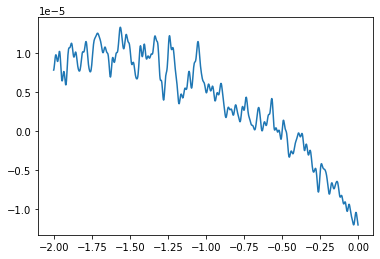

In [49]:
plt.figure()
plt.plot(epochs_act.times, np.mean(single_trial_erps_act.T,1))

(-0.00025, 0.00025)

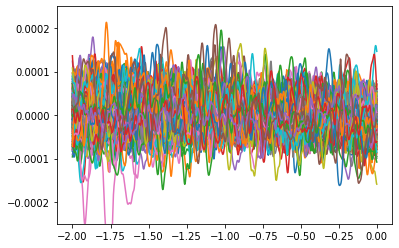

In [50]:
plt.figure()
plt.plot(epochs_act.times, single_trial_erps_act.T)
plt.ylim([-25e-5, 25e-5])

(12, 276)
55
Accuracy: 0.5727272727272728
Confusion Matrix:
[[37 18]
 [29 26]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.56      0.67      0.61        55
         1.0       0.59      0.47      0.53        55

    accuracy                           0.57       110
   macro avg       0.58      0.57      0.57       110
weighted avg       0.58      0.57      0.57       110



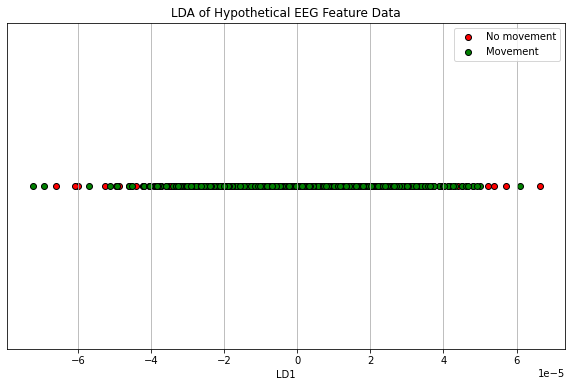

In [51]:
movement = np.array([np.mean(single_trial_erps_act[:,epochs_act.time_as_index(-1.2+i/10)[0]: epochs_act.time_as_index(-1.1+i/10)[0]], 1) for i in range(12)])
no_movement = np.array([np.mean(single_trial_erps_viz[:,epochs_act.time_as_index(-1.2+i/10)[0]: epochs_viz.time_as_index(-1.1+i/10)[0]], 1) for i in range(12)])
print(movement.shape)
nb_trials_per_fold = movement.shape[1] //5 # 5 fold meaning 20% test - 80% train
print(nb_trials_per_fold)
list_trials = np.arange(movement.shape[1])
list_trials_test = np.random.choice(list_trials, nb_trials_per_fold, replace=False)
list_trials_train = np.setdiff1d(list_trials, list_trials_test)
movement_train = movement[:,list_trials_train]
movement_test = movement[:,list_trials_test]


list_trials_test = np.random.choice(list_trials, nb_trials_per_fold, replace=False)
list_trials_train = np.setdiff1d(list_trials, list_trials_test)
no_movement_train = no_movement[:,list_trials_train]
no_movement_test = no_movement[:,list_trials_test]
X_train = np.concatenate([np.transpose(movement_train, (1,0)),np.transpose(no_movement_train, (1,0))])
X_test = np.concatenate([np.transpose(movement_test, (1,0)),np.transpose(no_movement_test, (1,0))])
y_train = np.concatenate([np.ones(X_train.shape[0]//2),np.zeros(X_train.shape[0]//2)])
y_test = np.concatenate([np.ones(X_test.shape[0]//2),np.zeros(X_test.shape[0]//2)])

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,recall_score
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
import matplotlib.pyplot as plt
# Perform LDA and cross-validation
lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit_transform(X_train, y_train)

# Predictions
y_pred = lda.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Plotting the results after LDA
plt.figure(figsize=(10, 6))
plt.scatter(X_test[y_test == 0], np.zeros(X_test[y_test == 0].shape), color='red', label='No movement', edgecolor='k')
plt.scatter(X_test[y_test == 1], np.zeros(X_test[y_test == 1].shape), color='green', label='Movement', edgecolor='k')
plt.title("LDA of Hypothetical EEG Feature Data")
plt.xlabel("LD1")
plt.yticks([])  # Hide y-axis
plt.legend()
plt.grid(True)
plt.show()

(12, 276)
55
Accuracy: 0.6727272727272727
Confusion Matrix:
[[37 18]
 [18 37]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.67      0.67        55
         1.0       0.67      0.67      0.67        55

    accuracy                           0.67       110
   macro avg       0.67      0.67      0.67       110
weighted avg       0.67      0.67      0.67       110



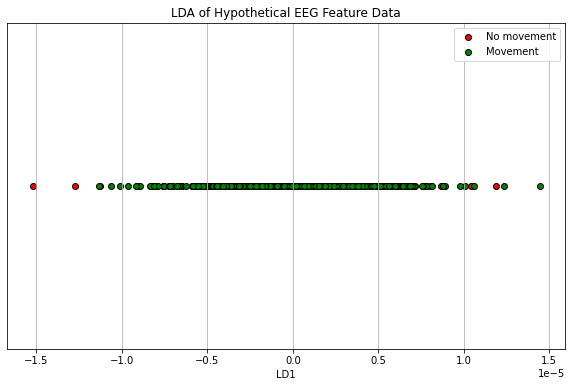

In [28]:
movement = np.array([np.mean(np.mean(epochs_act._data,1)[:,epochs_act.time_as_index(-1.2+i/10)[0]: epochs_act.time_as_index(-1.1+i/10)[0]], 1) for i in range(12)])
no_movement = np.array([np.mean(np.mean(epochs_viz._data,1)[:,epochs_act.time_as_index(-1.2+i/10)[0]: epochs_viz.time_as_index(-1.1+i/10)[0]], 1) for i in range(12)])
print(movement.shape)
nb_trials_per_fold = movement.shape[1] //5 # 5 fold meaning 20% test - 80% train
print(nb_trials_per_fold)
list_trials = np.arange(movement.shape[1])
list_trials_test = np.random.choice(list_trials, nb_trials_per_fold, replace=False)
list_trials_train = np.setdiff1d(list_trials, list_trials_test)
movement_train = movement[:,list_trials_train]
movement_test = movement[:,list_trials_test]


list_trials_test = np.random.choice(list_trials, nb_trials_per_fold, replace=False)
list_trials_train = np.setdiff1d(list_trials, list_trials_test)
no_movement_train = no_movement[:,list_trials_train]
no_movement_test = no_movement[:,list_trials_test]
X_train = np.concatenate([np.transpose(movement_train, (1,0)),np.transpose(no_movement_train, (1,0))])
X_test = np.concatenate([np.transpose(movement_test, (1,0)),np.transpose(no_movement_test, (1,0))])
y_train = np.concatenate([np.ones(X_train.shape[0]//2),np.zeros(X_train.shape[0]//2)])
y_test = np.concatenate([np.ones(X_test.shape[0]//2),np.zeros(X_test.shape[0]//2)])

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,recall_score
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
import matplotlib.pyplot as plt
# Perform LDA and cross-validation
lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit_transform(X_train, y_train)

# Predictions
y_pred = lda.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Plotting the results after LDA
plt.figure(figsize=(10, 6))
plt.scatter(X_test[y_test == 0], np.zeros(X_test[y_test == 0].shape), color='red', label='No movement', edgecolor='k')
plt.scatter(X_test[y_test == 1], np.zeros(X_test[y_test == 1].shape), color='green', label='Movement', edgecolor='k')
plt.title("LDA of Hypothetical EEG Feature Data")
plt.xlabel("LD1")
plt.yticks([])  # Hide y-axis
plt.legend()
plt.grid(True)
plt.show()